# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [167]:
coffee_df = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [168]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [169]:
# coffee_df.shape

print(f"The dataset contains {coffee_df.shape[0]} rows and {coffee_df.shape[1]} columns.")

The dataset contains 49894 rows and 13 columns.


##### 4.❓ Check the type of data in each column- do you notice any problems?

In [170]:
coffee_df.dtypes

transaction_date               str
transaction_time               str
customer_id                float64
quantity                     int64
line_item_amount           float64
unit_price                 float64
product_group                  str
product_category               str
product_type                   str
current_wholesale_price    float64
customer_since                 str
customer_birth_year        float64
customer_generation            str
dtype: object

> 👉 **Write Your Findings Here**: 
-- -
transaction_date, transaction_time, and customer_since are stored as text strings (str) instead of datetime objects, which will make time-based analysis difficult.

customer_id and customer_birth_year are stored as floats (float64) instead of integers. This indicates that these columns likely contain missing/null values, which pandas automatically converted to floats to accommodate the empty data."


##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [105]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])
coffee_df.dtypes

transaction_date           datetime64[us]
transaction_time                      str
customer_id                       float64
quantity                            int64
line_item_amount                  float64
unit_price                        float64
product_group                         str
product_category                      str
product_type                          str
current_wholesale_price           float64
customer_since             datetime64[us]
customer_birth_year               float64
customer_generation                   str
total_wholesale_amount            float64
profit                            float64
profit_ratio                      float64
transaction_day                       str
dtype: object

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [106]:
missing_percentage = (coffee_df.isna().sum() / len(coffee_df)) * 100
print(missing_percentage)

transaction_date            0.000000
transaction_time            0.000000
customer_id                50.143733
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.161825
customer_birth_year        50.161825
customer_generation        50.161825
total_wholesale_amount      0.000000
profit                      0.000000
profit_ratio                0.000000
transaction_day             0.000000
dtype: float64


👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [171]:
# how many duplicates we have
duplicate_count = coffee_df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 149


In [172]:
# Remove the duplicates and check if the total duplicates is 0 now

print("Original duplicates:", coffee_df.duplicated().sum())
coffee_df = coffee_df.drop_duplicates()
print("Duplicates after removal:", coffee_df.duplicated().sum())

Original duplicates: 149
Duplicates after removal: 0


##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [175]:
# unique values in product group
coffee_df['product_group'].unique()


<StringArray>
['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']
Length: 5, dtype: str

In [176]:
# unique values in product category
coffee_df['product_category'].unique()


<StringArray>
[               'Tea',             'Coffee', 'Drinking Chocolate',
             'Bakery',       'Coffee beans',           'Flavours',
          'Loose Tea', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

In [177]:
# unique values in product type
coffee_df['product_type'].unique()


<StringArray>
[      'Brewed Chai tea', 'Organic brewed coffee',      'Brewed Green tea',
           'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
      'Brewed Black tea',         'Hot chocolate',      'Barista Espresso',
                 'Scone',     'Brewed herbal tea',              'Biscotti',
                'Pastry',         'Organic Beans',         'Regular syrup',
            'Herbal tea',         'Gourmet Beans',             'Black tea',
      'Sugar free syrup',     'House blend Beans',         'Premium Beans',
              'Chai tea',     'Organic Chocolate',    'Drinking Chocolate',
           'Green beans',             'Green tea',        'Espresso Beans',
            'Housewares',              'Clothing']
Length: 29, dtype: str

In [178]:
# unique values in customer_generation
coffee_df['customer_generation'].unique()

<StringArray>
[  'Older Millennials',        'Baby Boomers',               'Gen Z',
               'Gen X', 'Younger Millennials',                   nan]
Length: 6, dtype: str

What inconsistencies do you notice?

When looking closely at the categorical data, a clear inconsistency stands out in the capitalization styles across and within columns; for instance, product_category uses Title Case for 'Drinking Chocolate' but switches to mixed case for 'Coffee beans' with a lowercase 'b', while product_type is a messy blend of lowercase and capitalized terms. Another major inconsistency is that 'nan' is listed as a unique category under customer_generation, which is incorrect because missing or null values should never be treated as an actual demographic group during analysis.

Is there a spelling consistency?

Yes, the spelling across all these columns is completely consistent and well-maintained. Core product terms like "Coffee", "Tea", and "Chocolate" are spelled correctly every time they appear, meaning there are no duplicate groups or typos that would split the data accidentally.

Do you need to fix anything?

Yes, a few things definitely need to be fixed before running any further analysis. First, the text formats should be standardized by using python functions to trim any accidental hidden spaces and convert the text into a unified case so everything groups together perfectly. Second, the 'nan' values in the customer_generation column must be filtered out or explicitly handled so they do not show up and ruin the generation-based charts.

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [179]:
coffee_df.describe(include='all')


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
count,49745,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745,49745,49745,49745.000000,24792,24792.000000,24792
unique,29,26074,NaN,NaN,NaN,NaN,5,9,29,NaN,794,NaN,5
top,2019-04-19,10:11:25,NaN,NaN,NaN,NaN,Beverages,Coffee,Brewed Chai tea,NaN,2017-11-03,NaN,Baby Boomers
freq,1905,11,NaN,NaN,NaN,NaN,38592,19634,5717,NaN,94,NaN,6002
mean,NaN,NaN,4582.647837,1.439481,4.687731,3.384018,NaN,NaN,NaN,1.354957,NaN,1978.248871,NaN
std,NaN,NaN,3247.554091,0.543316,4.441833,2.686402,NaN,NaN,NaN,2.204466,NaN,15.088333,NaN
min,NaN,NaN,1.000000,1.000000,0.000000,0.800000,NaN,NaN,NaN,0.040000,NaN,1950.000000,NaN
25%,NaN,NaN,584.000000,1.000000,3.000000,2.500000,NaN,NaN,NaN,0.600000,NaN,1965.000000,NaN
50%,NaN,NaN,5417.000000,1.000000,3.750000,3.000000,NaN,NaN,NaN,0.750000,NaN,1981.000000,NaN
75%,NaN,NaN,8099.000000,2.000000,6.000000,3.750000,NaN,NaN,NaN,1.950000,NaN,1992.000000,NaN


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:
>
> The summary statistics reveal important data distribution patterns and potential anomalies: most notably, the quantity column is right-skewed, with 75% of orders containing only two products or fewer while the maximum reaches 8, and the line_item_amount column has an unusual minimum value of 0.00 which could indicate potential errors or promotions. Additionally, a massive outlier is present where a single transaction peaks at 360.0 despite 75% of orders costing $6.00 or less. Operationally, Beverages is the dominant product group, led by Coffee as the top category and Brewed Chai tea as the most frequent product type (5,717 times). Lastly, Baby Boomers represent the most frequent loyalty customer demographic (6,002 transactions), within a customer age range spanning from 1950 to 2001.

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [180]:
coffee_df['total_wholesale_amount'] = coffee_df['current_wholesale_price'] * coffee_df['quantity']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [181]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74


##### 13.❓Find the highest sale price in the dataset.

In [182]:
highest_sale = coffee_df['line_item_amount'].max()
print("Highest sale price in the dataset:", highest_sale)


Highest sale price in the dataset: 360.0


##### 14.❓Find the largest amount of profit.

In [183]:
largest_profit = coffee_df['profit'].max()
print("Largest amount of profit :", largest_profit)


Largest amount of profit : 72.0


The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [184]:
mean_profit = coffee_df['profit'].mean()
print("mean of all the profit:", mean_profit)


mean of all the profit: 2.9367379636144335


##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [185]:
mean_transaction = coffee_df['line_item_amount'].mean()

transactions_above_mean = coffee_df[coffee_df['line_item_amount'] > mean_transaction].shape[0]

print(f"Mean transaction amount : {mean_transaction:.2f}")
print("Number of transactions were valued above the mean transaction amount:", transactions_above_mean)


Mean transaction amount : 4.69
Number of transactions were valued above the mean transaction amount: 19544


##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [186]:
coffee_df['profit_ratio'] = coffee_df['total_wholesale_amount'] / coffee_df['line_item_amount']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,0.252
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,0.252
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,0.252
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,0.252
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,0.252


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [187]:
high_profit_transactions = coffee_df[coffee_df['profit'] >= 2 * coffee_df['total_wholesale_amount']].shape[0]

print("Number of transactions made a profit of at least 2 times their wholesale cost:", high_profit_transactions)


Number of transactions made a profit of at least 2 times their wholesale cost: 37250


##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [122]:
beans_transactions = coffee_df[coffee_df['product_category'].str.contains('beans', case=False, na=False)].shape[0]

print("Number of transactions in the dataset were for coffee beans:", beans_transactions)


Number of transactions in the dataset were for coffee beans: 587


##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [123]:
coffee_df_sorted = coffee_df.sort_values(by='profit', ascending=False)

coffee_df_sorted.head(1)


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
49092,2019-04-17,09:55:47,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.0,NaT,NaN,NaN,288.0,72.0,0.8,Wednesday


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [192]:
loss_transactions = coffee_df[coffee_df['profit'] < 0].shape[0]

print("Number of transactions make a loss where the profit is less than 0 :", loss_transactions)


Number of transactions make a loss where the profit is less than 0 : 151


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


In [191]:
# FOR NOTICE
loss_df = coffee_df[coffee_df['profit'] < 0]
loss_df[['quantity', 'current_wholesale_price', 'total_wholesale_amount', 'line_item_amount', 'profit']].head(10)

,quantity,current_wholesale_price,total_wholesale_amount,line_item_amount,profit
37654,1,2.44,2.44,1.0,-1.44
37656,1,2.44,2.44,1.0,-1.44
37658,1,2.44,2.44,1.0,-1.44
37659,1,2.44,2.44,1.0,-1.44
37662,1,2.44,2.44,1.0,-1.44
37665,1,2.44,2.44,1.0,-1.44
37666,1,2.44,2.44,1.0,-1.44
37667,1,2.44,2.44,1.0,-1.44
37694,1,2.44,2.44,1.0,-1.44
37695,1,2.44,2.44,1.0,-1.44


##### Write your findindg here please:

Limited Anomalies: Out of the entire dataset, only 151 transactions resulted in a negative profit, indicating isolated errors rather than a business trend.

Fixed Price Mismatch: In all these losing rows, the retail price (line_item_amount) is stuck at exactly 1.00 while the actual wholesale cost is $2.44.

System/Data Entry Error: It is commercially unrealistic to repeatedly sell items below cost. This constant -$1.44 loss per transaction stems from a system glitch or placeholder value where the real retail prices were not captured.

##### 22.❓Correct the line item amount column with the correct values

In [193]:
coffee_df['line_item_amount'] = coffee_df['unit_price'] * coffee_df['quantity']


##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [194]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [195]:
updated_loss_count = coffee_df[coffee_df['profit'] < 0].shape[0]
print("Number of transactions that still make a loss:", updated_loss_count)


Number of transactions that still make a loss: 2


##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [196]:
product_counts = coffee_df['product_category'].value_counts()
print(product_counts)

product_category
Coffee                19634
Tea                   15125
Bakery                 7521
Drinking Chocolate     3833
Flavours               2248
Coffee beans            587
Loose Tea               401
Branded                 245
Packaged Chocolate      151
Name: count, dtype: int64


##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

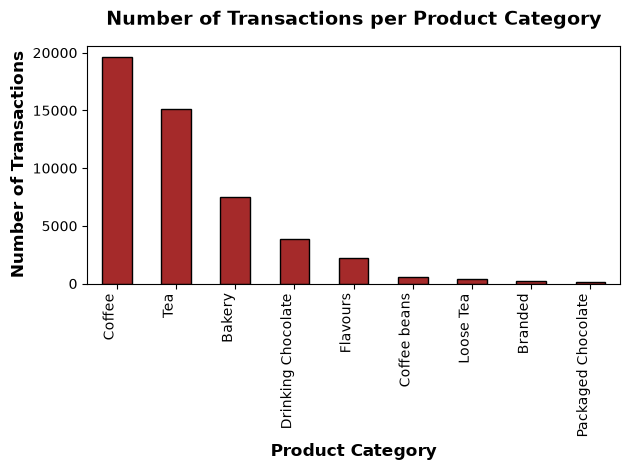

In [197]:

product_counts = coffee_df['product_category'].value_counts()

ax = product_counts.plot(kind='bar', color='darkcoffee' if 'darkcoffee' in plt.colormaps else 'brown', edgecolor='black')

plt.title('Number of Transactions per Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()


##### 27.❓Can you calculate the median profit for each product type?

In [198]:
median_profit_per_type = coffee_df.groupby('product_type')['profit'].median()

print(median_profit_per_type)


product_type
Barista Espresso          3.40
Biscotti                  1.22
Black tea                 1.79
Brewed Black tea          3.74
Brewed Chai tea           3.74
Brewed Green tea          3.74
Brewed herbal tea         3.74
Chai tea                  1.90
Clothing                 19.04
Drinking Chocolate        2.67
Drip coffee               2.40
Espresso Beans            2.95
Gourmet Beans             4.20
Gourmet brewed coffee     3.20
Green beans               2.00
Green tea                 1.85
Herbal tea                1.79
Hot chocolate             1.74
House blend Beans         3.60
Housewares                9.52
Organic Beans             3.60
Organic Chocolate         1.52
Organic brewed coffee     3.52
Pastry                    1.31
Premium Beans             9.00
Premium brewed coffee     3.92
Regular syrup             1.52
Scone                     1.14
Sugar free syrup          1.52
Name: profit, dtype: float64


##### 28.❓Create a column that shows the transaction_day



In [201]:
coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day_name()# to show day name
#if we want ro show the num od day coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day
coffee_df.head(90)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,0.252,Monday
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,0.252,Monday
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,0.252,Monday
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,0.252,Monday
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,0.252,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,2019-04-03,12:42:56,5150.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-12-11,1993.0,Younger Millennials,0.63,1.87,0.252,Wednesday
86,2019-04-03,09:00:48,5360.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-12-26,1972.0,Gen X,0.63,1.87,0.252,Wednesday
87,2019-04-03,15:30:39,5242.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-09-18,1996.0,Gen Z,0.63,1.87,0.252,Wednesday
88,2019-04-03,11:20:52,5782.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-02-14,1952.0,Baby Boomers,0.63,1.87,0.252,Wednesday


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [202]:
day_revenue = coffee_df.groupby('transaction_day')['line_item_amount'].sum()

print(day_revenue.sort_values(ascending=False))
#Yes, there is a noticeable relationship. Total revenue peaks significantly at the beginning of the traditional workweek and drops to its lowest on the weekend.

transaction_day
Monday       39563.74
Wednesday    34374.03
Tuesday      32371.81
Friday       32304.55
Saturday     32138.85
Thursday     31902.82
Sunday       31014.75
Name: line_item_amount, dtype: float64


##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

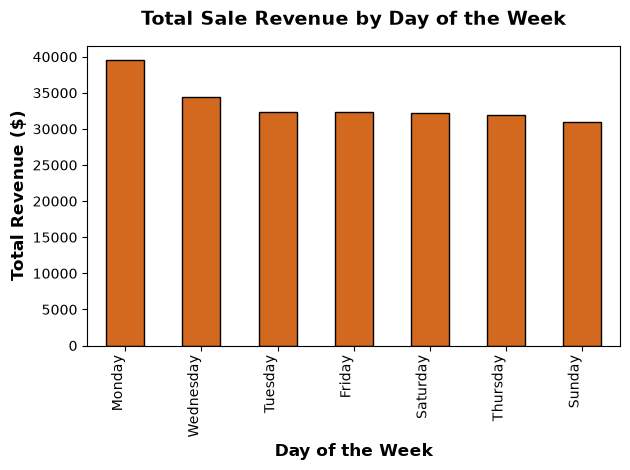

In [203]:
day_revenue = coffee_df.groupby('transaction_day')['line_item_amount'].sum().sort_values(ascending=False)

ax = day_revenue.plot(kind='bar', color='chocolate', edgecolor='black')

plt.title('Total Sale Revenue by Day of the Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()


##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [204]:
generation_spending = coffee_df.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending=False)

print(generation_spending)

customer_generation
Baby Boomers           27295.04
Gen X                  26739.61
Older Millennials      25166.90
Gen Z                  19716.40
Younger Millennials    15414.78
Name: line_item_amount, dtype: float64


##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

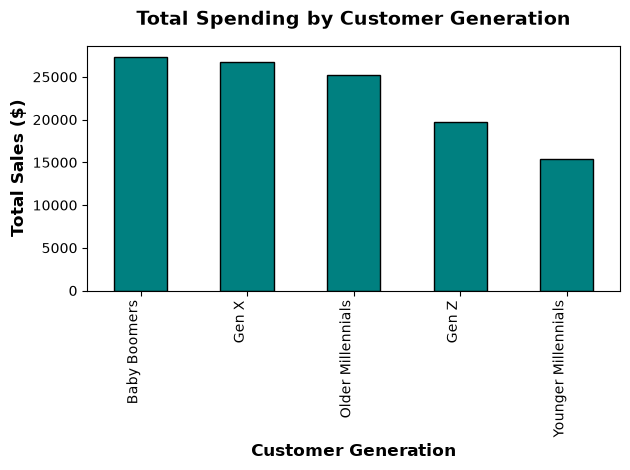

In [205]:

generation_spending = coffee_df.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending=False)

ax = generation_spending.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Total Spending by Customer Generation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Generation', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [137]:
top_5_profitable_products = coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5)

print(top_5_profitable_products)


product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11829.56
Name: profit, dtype: float64


##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

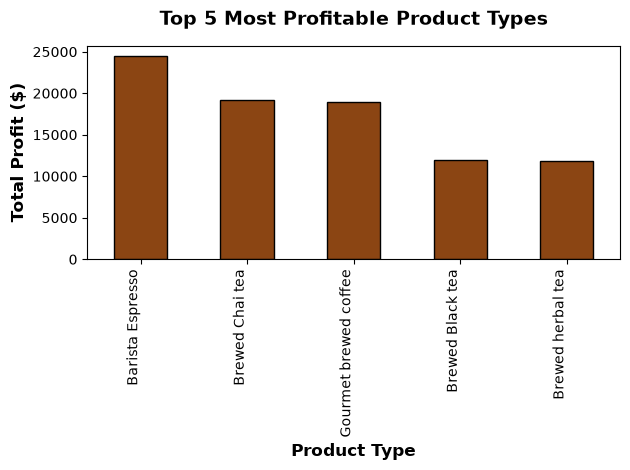

In [138]:

top_5_profitable_products = coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5)

ax = top_5_profitable_products.plot(kind='bar', color='saddlebrown', edgecolor='black')

plt.title('Top 5 Most Profitable Product Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Type', fontsize=12, fontweight='bold')
plt.ylabel('Total Profit ($)', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()


##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [139]:
segment_profit_ratio = coffee_df.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending=False)

print(segment_profit_ratio)


customer_generation
Gen X                  0.337172
Gen Z                  0.334760
Older Millennials      0.334465
Baby Boomers           0.333038
Younger Millennials    0.332600
Name: profit_ratio, dtype: float64


##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

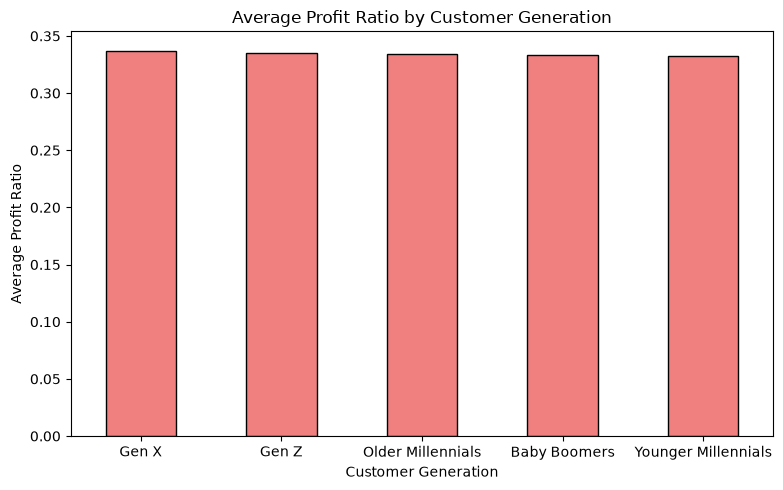

In [209]:
segment_profit_ratio.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(8, 5))

plt.title('Average Profit Ratio by Customer Generation')
plt.xlabel('Customer Generation')
plt.ylabel('Average Profit Ratio')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



## Part C : Dig Deeper

In [141]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,0.252,Monday
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,0.252,Monday
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,0.252,Monday
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,0.252,Monday
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,0.252,Monday


In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

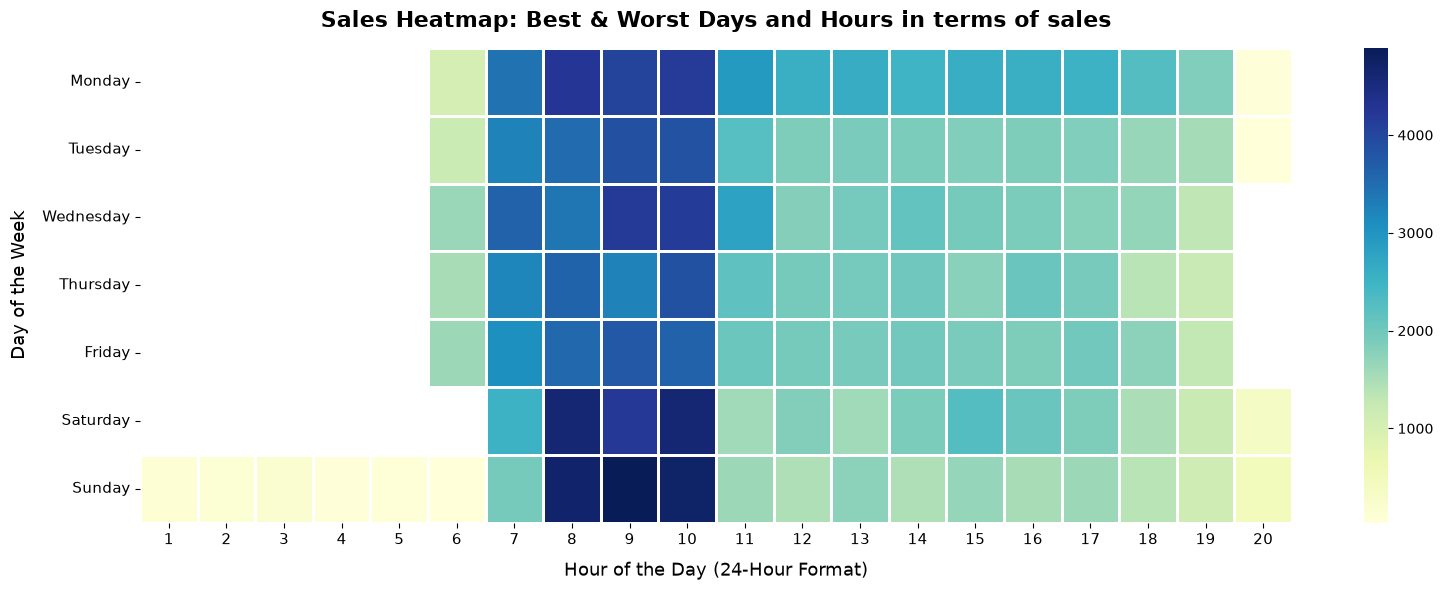

In [218]:
coffee_df['hour'] = pd.to_datetime(coffee_df['transaction_time'], format='%H:%M:%S').dt.hour

heatmap_data = coffee_df.pivot_table(index='transaction_day', columns='hour', values='line_item_amount', aggfunc='sum')

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.8, cbar=True)

plt.title('Sales Heatmap: Best & Worst Days and Hours in terms of sales', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=13, labelpad=10)
plt.ylabel('Day of the Week', fontsize=13, labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [219]:
# Extracting dates from transaction date
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])

coffee_df['year'] = coffee_df['transaction_date'].dt.year
coffee_df['month_number'] = coffee_df['transaction_date'].dt.month

coffee_df['day_name'] = coffee_df['transaction_date'].dt.day_name()
coffee_df['day_number'] = coffee_df['transaction_date'].dt.day

coffee_df[['transaction_date', 'year', 'month_number','day_number','day_name']].tail()

,transaction_date,year,month_number,day_number,day_name
49889,2019-04-24,2019,4,24,Wednesday
49890,2019-04-25,2019,4,25,Thursday
49891,2019-04-25,2019,4,25,Thursday
49892,2019-04-25,2019,4,25,Thursday
49893,2019-04-25,2019,4,25,Thursday


In [155]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time

def get_time_category(time_val):
    if isinstance(time_val, str):
        hour = pd.to_datetime(time_val, format='%H:%M:%S').hour
    else:
        hour = time_val.hour
        
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Noon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# use apply to apply the time category into a new column called time_category
coffee_df['time_category'] = coffee_df['transaction_time'].apply(get_time_category)

coffee_df[['transaction_time', 'time_category']].head()


,transaction_time,time_category
0,12:04:43,Noon
1,11:15:38,Morning
2,12:05:31,Noon
3,16:49:38,Noon
4,19:17:34,Evening


In [161]:
# Are there better or worse days/times in terms of sales?
sales_by_day_time = coffee_df.groupby(['transaction_day', 'time_category'])['line_item_amount'].sum().sort_values(ascending=False)

print("Best Times for Sales :")
print(sales_by_day_time.head(3))

print("\nWorst Times for Sales :")
print(sales_by_day_time.tail(3))

# Write your findings

Best Times for Sales :
transaction_day  time_category
Monday           Morning          19933.20
Wednesday        Morning          19834.03
Sunday           Morning          17991.36
Name: line_item_amount, dtype: float64

Worst Times for Sales :
transaction_day  time_category
Sunday           Evening          4623.88
Thursday         Evening          4520.18
Sunday           Night             525.53
Name: line_item_amount, dtype: float64


> 👉 **Write Your Findings Here**: 
-- -
>
The Best Times for Sales: The data clearly shows that Mornings are the absolute peak for sales revenue across the week, with Monday Morning 19933.20 and Wednesday Morning 19834.03 bringing in the highest amounts due to the weekday coffee rush. Interestingly, even Sunday Morning performs very well $17991.36.

The Worst Times for Sales: On the other hand, late hours and evenings see a major drop in traffic. Sunday Night is by far the absolute worst-performing time bringing in only 525.53 followed by Thursday Evening 4520.18 and Sunday Evening $4,623.88.

Business Takeaway: We should maximize our staffing and inventory during weekday mornings to handle the high demand, and consider special promotions or closing earlier on Sunday nights since the sales drop significantly.

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

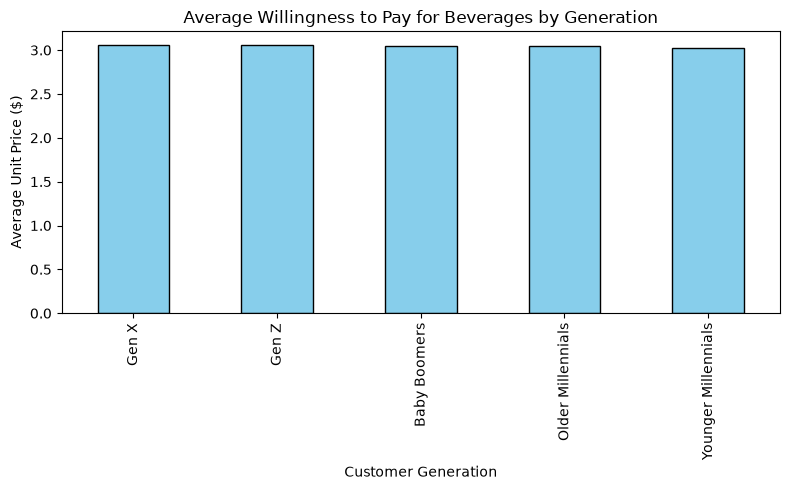

In [220]:
# Does customers’ willingness to pay for Beverages vary by generation?

beverages_df = coffee_df[coffee_df['product_group'] == 'Beverages']

generation_wtp = beverages_df.groupby('customer_generation')['unit_price'].mean().sort_values(ascending=False)

generation_wtp.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(8, 5))

plt.title('Average Willingness to Pay for Beverages by Generation')
plt.xlabel('Customer Generation')
plt.ylabel('Average Unit Price ($)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Write your findings

> 👉 **Write Your Findings Here**: 
--
>
> No Significant Variation: The data reveals that customers' willingness to pay for beverages does not significantly vary by generation.
> Consistent Spending: Across all groups Gen X, Gen Z, Baby Boomers, Older Millennials, and Younger Millennials the average unit price spent on beverages remains highly consistent, hovering right around the $3.00 mark.
> Key Insight: This suggests that beverage pricing appeals equally to all age groups, and there is no specific generation driving premium-priced beverage sales over another in this dataset.

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

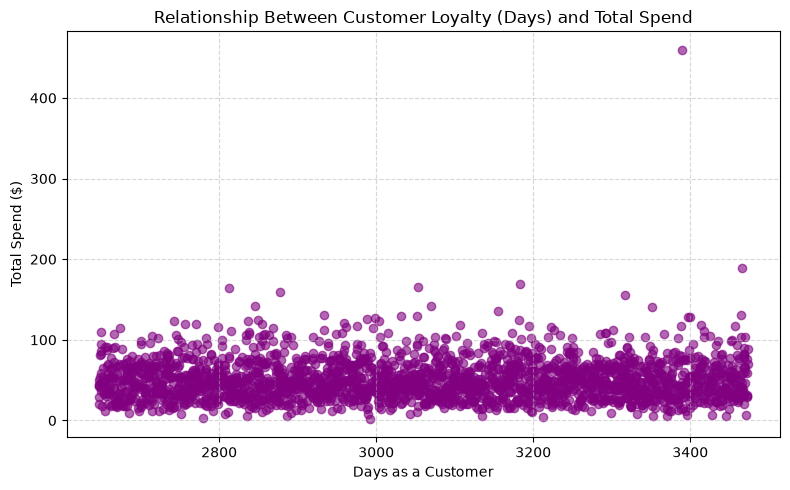

In [226]:
from datetime import date
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])

today = pd.to_datetime(date.today())
coffee_df['days_as_customer'] = (today - coffee_df['customer_since']).dt.days

customer_stats = coffee_df.groupby('customer_id').agg({
    'days_as_customer': 'first', 
    'line_item_amount': 'sum'          
})

plt.figure(figsize=(8, 5))
plt.scatter(customer_stats['days_as_customer'], customer_stats['line_item_amount'], color='purple', alpha=0.6)

plt.title("Relationship Between Customer Loyalty (Days) and Total Spend")
plt.xlabel("Days as a Customer")
plt.ylabel("Total Spend ($)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()